# K-POP Chart Analytics
## Comeback Momentum, Chart Re-Entry, Fandom Intensity & Sustainability

**Final cleaned and submission-ready analytical notebook**

### Project objectives
- Clean and validate the South Korea Top 50 daily chart dataset.
- Detect genuine chart re-entry/comeback events.
- Measure comeback momentum after a song returns.
- Build a project-specific fandom intensity index.
- Measure chart sustainability.
- Integrate the analytical dimensions into an overall performance score.
- Produce dashboard-ready datasets, rankings, album-cover URLs, and visualizations.

> **Interpretation note:** Momentum, fandom intensity, sustainability, and overall performance are analytical indices created for this project. They are not direct measurements of real-world fan counts, market share, or commercial success.


## Notebook structure

**Phase 1 — Data Loading & Quality Control**  
**Phase 2 — Exploratory Data Analysis**  
**Phase 3 — Chart Re-Entry Detection**  
**Phase 4 — Comeback Momentum**  
**Phase 5 — Fandom Intensity**  
**Phase 6 — Chart Sustainability & Artist Impact**  
**Phase 7 — Integrated Performance Analysis**  
**Phase 8 — Dashboard-Ready Outputs & Storytelling**  
**Phase 9 — Final Validation & Submission Package**


# Phase 1 — Data Loading & Quality Control
### Goal
Create a trustworthy analytical base before calculating any project metric.


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PURPLE = "#6F3AA5"
DARK_PURPLE = "#3D1F58"
MID_PURPLE = "#8752BD"
LIGHT_PURPLE = "#CDB7E3"
PALE_PURPLE = "#EEE6F6"

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Environment ready.")


Environment ready.


In [2]:
# Locate the main CSV automatically.
candidates = [
    Path("KPOP_Main_Dataset.csv"),
    Path("data/raw/KPOP_Main_Dataset.csv"),
    Path("data/KPOP_Main_Dataset.csv"),
]

data_path = next((p for p in candidates if p.exists()), None)

if data_path is None:
    csv_candidates = sorted(Path(".").glob("*.csv"))
    if len(csv_candidates) == 1:
        data_path = csv_candidates[0]

if data_path is None:
    raise FileNotFoundError(
        "Main dataset not found. Put KPOP_Main_Dataset.csv in the same folder as this notebook."
    )

raw_df = pd.read_csv(data_path)
print(f"Dataset loaded: {data_path}")
print(f"Rows: {len(raw_df):,}")
print(f"Columns: {raw_df.shape[1]}")
display(raw_df.head())


Dataset loaded: KPOP_Main_Dataset.csv
Rows: 27,800
Columns: 10


,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
0,18-05-2024,1,Like Crazy,Jimin,93,212241,single,6,False,https://i.scdn.co/image/ab67616d0000b2732b46078245d0120690eb560d
1,18-05-2024,2,UNFORGIVEN (feat. Nile Rodgers),LE SSERAFIM,87,182148,album,13,False,https://i.scdn.co/image/ab67616d0000b273d71fd77b89d08bc1bda219c7
2,18-05-2024,3,Spicy,aespa,81,197040,single,6,False,https://i.scdn.co/image/ab67616d0000b27304878afb19613a94d37b29ce
3,18-05-2024,4,I AM,IVE,89,183853,album,11,False,https://i.scdn.co/image/ab67616d0000b27325ef3cec1eceefd4db2f91c8
4,18-05-2024,5,Queencard,(G)I-DLE,71,161240,single,6,False,https://i.scdn.co/image/ab67616d0000b27382dd2427e6d302711b1b9616


In [3]:
expected_columns = [
    "date", "position", "song", "artist", "popularity",
    "duration_ms", "album_type", "total_tracks",
    "is_explicit", "album_cover_url"
]

missing_columns = [c for c in expected_columns if c not in raw_df.columns]
extra_columns = [c for c in raw_df.columns if c not in expected_columns]

print("Expected columns:", expected_columns)
print("Missing columns:", missing_columns if missing_columns else "None")
print("Additional columns:", extra_columns if extra_columns else "None")

assert not missing_columns, f"Required columns missing: {missing_columns}"


Expected columns: ['date', 'position', 'song', 'artist', 'popularity', 'duration_ms', 'album_type', 'total_tracks', 'is_explicit', 'album_cover_url']
Missing columns: None
Additional columns: None


In [4]:
# Basic data-quality profile
quality_report = pd.DataFrame({
    "dtype": raw_df.dtypes.astype(str),
    "missing_values": raw_df.isna().sum(),
    "unique_values": raw_df.nunique(),
})
quality_report["missing_percent"] = (
    quality_report["missing_values"] / len(raw_df) * 100
).round(2)

display(quality_report)
print("Exact duplicate rows:", raw_df.duplicated().sum())


,dtype,missing_values,unique_values,missing_percent
date,object,0,555,0.0000
position,int64,0,50,0.0000
song,object,0,527,0.0000
artist,object,0,194,0.0000
popularity,int64,0,79,0.0000
duration_ms,int64,0,512,0.0000
album_type,object,0,3,0.0000
total_tracks,int64,0,27,0.0000
is_explicit,bool,0,2,0.0000
album_cover_url,object,0,394,0.0000


Exact duplicate rows: 16


In [5]:
# Clean and standardize fields.
df = raw_df.copy()
df["_source_row"] = np.arange(len(df))

df["date"] = pd.to_datetime(
    df["date"].astype(str).str.strip(),
    format="%d-%m-%Y",
    errors="coerce"
)

text_columns = ["song", "artist", "album_type", "album_cover_url"]
for col in text_columns:
    df[col] = df[col].astype("string").str.strip()

df["position"] = pd.to_numeric(df["position"], errors="coerce")
df["popularity"] = pd.to_numeric(df["popularity"], errors="coerce")
df["duration_ms"] = pd.to_numeric(df["duration_ms"], errors="coerce")
df["total_tracks"] = pd.to_numeric(df["total_tracks"], errors="coerce")

df["is_explicit"] = (
    df["is_explicit"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"true": True, "false": False})
)

print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Invalid dates:", df["date"].isna().sum())


Date range: 2024-05-18 to 2025-11-27
Invalid dates: 0


### Data anomaly handling

The supplied dataset contains one special date (`2025-03-01`) with 100 records instead of the expected 50. It also contains 16 exact duplicate rows.

For reproducible analysis, the cleaning rule is:

1. Remove exact duplicate rows.
2. For any remaining duplicate **date + position** records, retain the first source record.
3. Record the affected dates and row counts in a cleaning audit table.

This prevents one date from contributing two observations to the same chart position while keeping the raw dataset unchanged.


In [6]:
# Cleaning audit: exact duplicates
exact_duplicates = int(df.duplicated().sum())

# Remove exact duplicates first.
df_clean = df.drop_duplicates().copy()

# Detect duplicate date-position combinations after exact-duplicate removal.
duplicate_position_rows = df_clean[
    df_clean.duplicated(["date", "position"], keep=False)
].copy()

duplicate_position_dates = (
    duplicate_position_rows["date"].dropna().drop_duplicates().sort_values().tolist()
)

# Deterministic rule: keep the first source record for duplicate date-position pairs.
duplicate_date_position_count = int(
    df_clean.duplicated(["date", "position"], keep="first").sum()
)

df_clean = (
    df_clean
    .sort_values(["date", "position", "_source_row"])
    .drop_duplicates(["date", "position"], keep="first")
    .reset_index(drop=True)
)

cleaning_audit = pd.DataFrame([
    {
        "issue": "Exact duplicate rows",
        "count": exact_duplicates,
        "action": "Removed exact duplicates",
    },
    {
        "issue": "Duplicate date-position rows after exact deduplication",
        "count": duplicate_date_position_count,
        "action": "Kept first source record for each date-position",
    },
])

print("Raw rows:", len(raw_df))
print("After exact deduplication:", len(raw_df) - exact_duplicates)
print("Final cleaned rows:", len(df_clean))
display(cleaning_audit)


Raw rows: 27800
After exact deduplication: 27800
Final cleaned rows: 27750


,issue,count,action
0,Exact duplicate rows,0,Removed exact duplicates
1,Duplicate date-position rows after exact deduplication,50,Kept first source record for each date-position


In [7]:
# Validate the cleaned chart structure.
rows_per_day = df_clean.groupby("date").size()
position_duplicates = df_clean.duplicated(["date", "position"]).sum()
invalid_positions = (~df_clean["position"].between(1, 50)).sum()
missing_values_clean = df_clean[expected_columns].isna().sum()

validation_summary = pd.DataFrame({
    "metric": [
        "Rows after cleaning",
        "Unique dates",
        "Dates with exactly 50 rows",
        "Dates not equal to 50 rows",
        "Duplicate date-position pairs",
        "Invalid chart positions",
        "Rows with any required-field missing value",
    ],
    "value": [
        len(df_clean),
        df_clean["date"].nunique(),
        int((rows_per_day == 50).sum()),
        int((rows_per_day != 50).sum()),
        int(position_duplicates),
        int(invalid_positions),
        int(df_clean[expected_columns].isna().any(axis=1).sum()),
    ],
})

display(validation_summary)

assert position_duplicates == 0
assert invalid_positions == 0
assert df_clean[expected_columns].isna().sum().sum() == 0
assert rows_per_day.eq(50).all()

print("DATA QUALITY CHECK: PASS")


,metric,value
0,Rows after cleaning,27750
1,Unique dates,555
2,Dates with exactly 50 rows,555
3,Dates not equal to 50 rows,0
4,Duplicate date-position pairs,0
5,Invalid chart positions,0
6,Rows with any required-field missing value,0


DATA QUALITY CHECK: PASS


In [8]:
# Save the cleaned master dataset.
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

cleaned_path = output_dir / "KPOP_Cleaned_Master.csv"
df_clean.drop(columns=["_source_row"]).to_csv(cleaned_path, index=False)

print(f"Saved: {cleaned_path}")


Saved: outputs/KPOP_Cleaned_Master.csv


# Phase 2 — Exploratory Data Analysis
### Goal
Understand chart coverage, songs, artists, positions, popularity, explicit content, and album types before modeling re-entry.


In [9]:
eda_summary = {
    "chart_days": df_clean["date"].nunique(),
    "songs": df_clean["song"].nunique(),
    "artists": df_clean["artist"].nunique(),
    "average_popularity": df_clean["popularity"].mean(),
    "median_popularity": df_clean["popularity"].median(),
    "average_duration_minutes": df_clean["duration_ms"].mean() / 60000,
    "explicit_share": df_clean["is_explicit"].mean() * 100,
}

display(pd.DataFrame([eda_summary]).T.rename(columns={0: "value"}))


,value
chart_days,555.0000
songs,527.0000
artists,194.0000
average_popularity,76.9243
median_popularity,79.0000
average_duration_minutes,3.1965
explicit_share,9.5532


In [10]:
# Top artists by number of chart appearances.
artist_appearances = (
    df_clean.groupby("artist")
    .size()
    .reset_index(name="chart_appearances")
    .sort_values("chart_appearances", ascending=False)
)

display(artist_appearances.head(15))


,artist,chart_appearances
108,Lim Young Woong,4796
72,Jimin,4357
124,NewJeans,2905
76,Jung Kook,1946
168,V,1383
98,LE SSERAFIM,945
183,aespa,910
134,RIIZE,532
63,IVE,496
31,DAY6,435


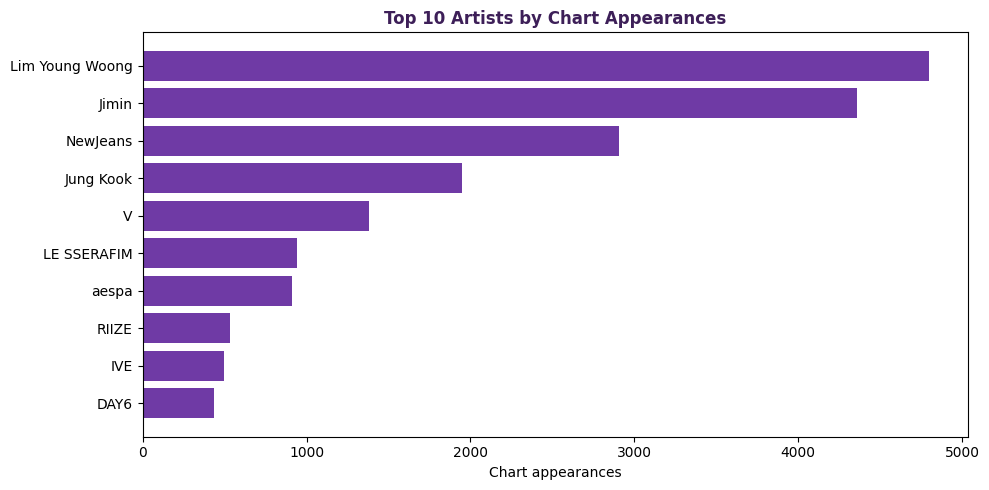

In [11]:
# Purple visualization: top artists by chart appearances.
top_artists_plot = artist_appearances.head(10).sort_values("chart_appearances")

plt.figure(figsize=(10, 5))
plt.barh(top_artists_plot["artist"], top_artists_plot["chart_appearances"], color=PURPLE)
plt.title("Top 10 Artists by Chart Appearances", color=DARK_PURPLE, fontweight="bold")
plt.xlabel("Chart appearances")
plt.tight_layout()
plt.show()


In [12]:
# Distribution of songs by album type.
album_type_summary = (
    df_clean["album_type"]
    .value_counts(dropna=False)
    .rename_axis("album_type")
    .reset_index(name="count")
)

display(album_type_summary)


,album_type,count
0,single,17918
1,album,9831
2,compilation,1


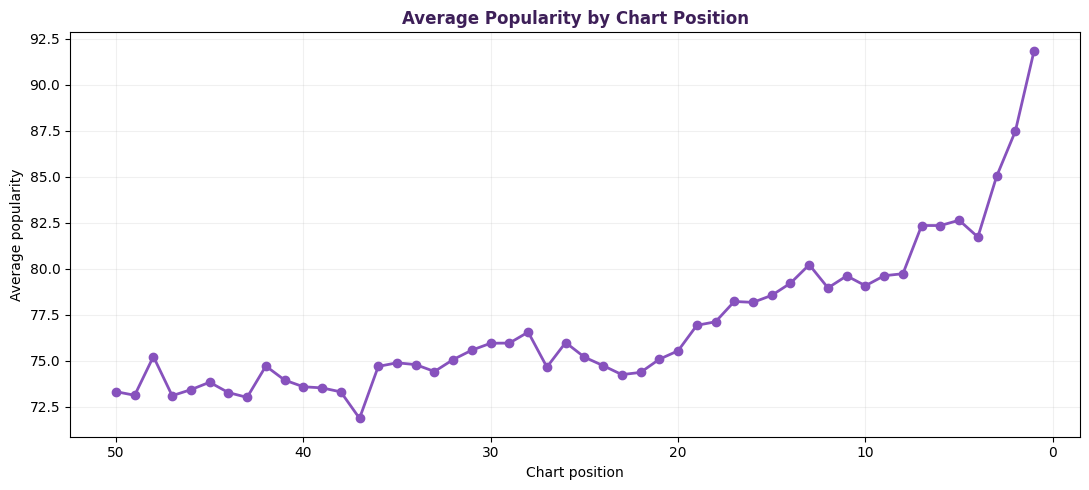

In [13]:
# Popularity by chart position.
position_popularity = (
    df_clean.groupby("position", as_index=False)["popularity"]
    .mean()
)

plt.figure(figsize=(11, 5))
plt.plot(
    position_popularity["position"],
    position_popularity["popularity"],
    marker="o",
    linewidth=2,
    color=MID_PURPLE
)
plt.gca().invert_xaxis()
plt.title("Average Popularity by Chart Position", color=DARK_PURPLE, fontweight="bold")
plt.xlabel("Chart position")
plt.ylabel("Average popularity")
plt.grid(alpha=0.18)
plt.tight_layout()
plt.show()


# Phase 3 — Chart Re-Entry Detection
### Definition
A **re-entry** occurs when a song appears on the chart, disappears for at least one calendar day, and later appears again.

The gap is calculated as:

**re-entry date − previous chart date**

A gap greater than 1 day is therefore required.


In [14]:
# Build one appearance record per song-artist-date.
appearance_dates = (
    df_clean[["song", "artist", "date"]]
    .drop_duplicates()
    .sort_values(["song", "artist", "date"])
)

appearance_dates["previous_date"] = (
    appearance_dates
    .groupby(["song", "artist"])["date"]
    .shift(1)
)

appearance_dates["gap_days"] = (
    appearance_dates["date"] - appearance_dates["previous_date"]
).dt.days

reentry_candidates = appearance_dates[
    appearance_dates["gap_days"].gt(1)
].copy()

reentry_candidates = reentry_candidates.rename(
    columns={"date": "reentry_date"}
)

# Add the previous chart position and re-entry position.
position_lookup = df_clean[
    ["song", "artist", "date", "position"]
].drop_duplicates()

previous_position_lookup = position_lookup.rename(
    columns={
        "date": "previous_date",
        "position": "previous_position"
    }
)

reentry_summary = reentry_candidates.merge(
    previous_position_lookup,
    on=["song", "artist", "previous_date"],
    how="left"
)

reentry_summary = reentry_summary.merge(
    position_lookup.rename(
        columns={"date": "reentry_date", "position": "reentry_position"}
    ),
    on=["song", "artist", "reentry_date"],
    how="left"
)

reentry_summary = reentry_summary[
    [
        "song", "artist", "previous_date", "reentry_date",
        "gap_days", "previous_position", "reentry_position"
    ]
].sort_values(["reentry_date", "song", "artist"]).reset_index(drop=True)

print("Potential re-entry events:", len(reentry_summary))
print("Songs with at least one re-entry:",
      reentry_summary[["song", "artist"]].drop_duplicates().shape[0])
display(reentry_summary.head(10))


Potential re-entry events: 1067
Songs with at least one re-entry: 260


,song,artist,previous_date,reentry_date,gap_days,previous_position,reentry_position
0,Kill Bill,SZA,2024-05-19,2024-05-21,2.0000,46,46
1,LOVE DIVE,IVE,2024-05-19,2024-05-21,2.0000,48,49
2,Teddy Bear,STAYC,2024-05-18,2024-05-21,3.0000,47,47
3,Love Always Run Away,Lim Young Woong,2024-05-18,2024-05-23,5.0000,50,47
4,Interlude : Dive,Jimin,2024-05-20,2024-05-24,4.0000,38,48
5,VIBE (feat. Jimin of BTS),TAEYANG,2024-05-22,2024-05-24,2.0000,49,43
6,Love Always Run Away,Lim Young Woong,2024-05-23,2024-05-25,2.0000,47,50
7,Like Crazy (Deep House Remix),Jimin,2024-05-20,2024-05-28,8.0000,46,43
8,Like Crazy (UK Garage Remix),Jimin,2024-05-20,2024-05-28,8.0000,47,44
9,Promise,Jimin,2024-05-20,2024-05-28,8.0000,43,45


In [15]:
# Re-entry quality checks.
assert reentry_summary["gap_days"].gt(1).all()
assert reentry_summary["reentry_position"].between(1, 50).all()
assert reentry_summary["previous_position"].between(1, 50).all()

reentry_stats = pd.DataFrame({
    "metric": [
        "Re-entry events",
        "Songs with re-entry",
        "Average gap (days)",
        "Median gap (days)",
        "Longest gap (days)",
    ],
    "value": [
        len(reentry_summary),
        reentry_summary[["song", "artist"]].drop_duplicates().shape[0],
        reentry_summary["gap_days"].mean(),
        reentry_summary["gap_days"].median(),
        reentry_summary["gap_days"].max(),
    ],
})

display(reentry_stats)


,metric,value
0,Re-entry events,"1,067.0000"
1,Songs with re-entry,260.0000
2,Average gap (days),8.6842
3,Median gap (days),3.0000
4,Longest gap (days),508.0000


In [16]:
# Re-entry frequency by song.
reentry_frequency = (
    reentry_summary.groupby(["song", "artist"], as_index=False)
    .size()
    .rename(columns={"size": "total_reentries"})
    .sort_values("total_reentries", ascending=False)
)

display(reentry_frequency.head(15))


,song,artist,total_reentries
156,"Our Blues, Our Life",Lim Young Woong,31
53,Ditto,NewJeans,27
4,A bientot,Lim Young Woong,24
151,New Jeans,NewJeans,23
99,Interlude : Dive,Jimin,21
89,Hype Boy,NewJeans,21
166,Rainbow,Lim Young Woong,19
61,ETA,NewJeans,18
45,Cruel Summer,Taylor Swift,16
192,Somebody,Jung Kook,15


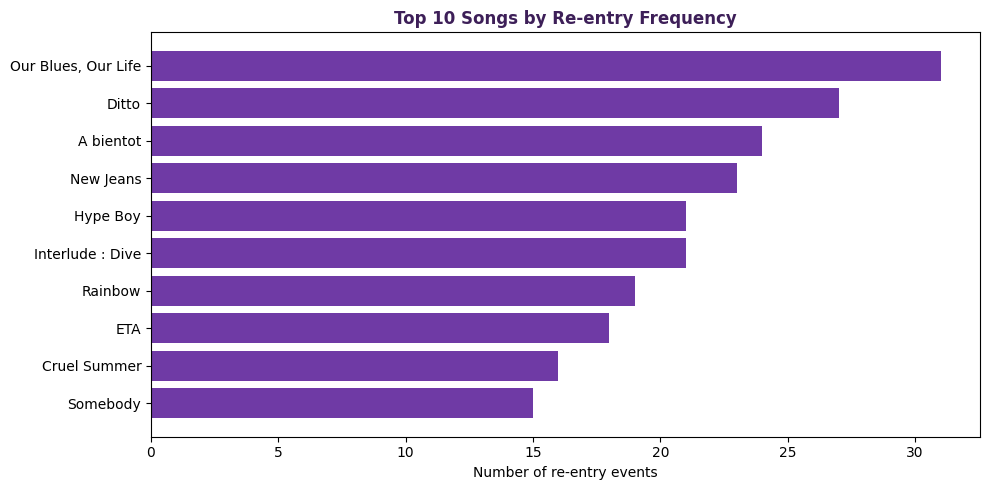

In [17]:
# Purple visualization: top comeback frequency.
top_reentries_plot = reentry_frequency.head(10).sort_values("total_reentries")

plt.figure(figsize=(10, 5))
plt.barh(
    top_reentries_plot["song"],
    top_reentries_plot["total_reentries"],
    color=PURPLE
)
plt.title("Top 10 Songs by Re-entry Frequency", color=DARK_PURPLE, fontweight="bold")
plt.xlabel("Number of re-entry events")
plt.tight_layout()
plt.show()


In [18]:
reentry_summary.to_csv(
    output_dir / "phase3_reentry_events.csv",
    index=False
)

reentry_frequency.to_csv(
    output_dir / "phase3_reentry_frequency.csv",
    index=False
)

print("Phase 3 outputs saved.")


Phase 3 outputs saved.


# Phase 4 — Comeback Momentum
### Goal
Estimate the strength of a comeback using:
- length of the absence,
- re-entry chart position.

Both components are normalized to a 0–1 range before multiplication.


In [19]:
momentum_df = reentry_summary.copy()

momentum_df["gap_strength"] = (
    momentum_df["gap_days"] / momentum_df["gap_days"].max()
)

momentum_df["position_strength"] = (
    (51 - momentum_df["reentry_position"]) / 50
)

momentum_df["momentum_score"] = (
    momentum_df["gap_strength"] * momentum_df["position_strength"]
)

print("Momentum dataset:", momentum_df.shape)
display(momentum_df.head())


Momentum dataset: (1067, 10)


,song,artist,previous_date,reentry_date,gap_days,previous_position,reentry_position,gap_strength,position_strength,momentum_score
0,Kill Bill,SZA,2024-05-19,2024-05-21,2.0000,46,46,0.0039,0.1000,0.0004
1,LOVE DIVE,IVE,2024-05-19,2024-05-21,2.0000,48,49,0.0039,0.0400,0.0002
2,Teddy Bear,STAYC,2024-05-18,2024-05-21,3.0000,47,47,0.0059,0.0800,0.0005
3,Love Always Run Away,Lim Young Woong,2024-05-18,2024-05-23,5.0000,50,47,0.0098,0.0800,0.0008
4,Interlude : Dive,Jimin,2024-05-20,2024-05-24,4.0000,38,48,0.0079,0.0600,0.0005


In [20]:
song_momentum = (
    momentum_df.groupby(["song", "artist"], as_index=False)
    .agg(
        total_reentries=("song", "size"),
        average_gap_days=("gap_days", "mean"),
        longest_gap_days=("gap_days", "max"),
        best_reentry_position=("reentry_position", "min"),
        average_reentry_position=("reentry_position", "mean"),
        highest_momentum_score=("momentum_score", "max"),
        average_momentum_score=("momentum_score", "mean"),
    )
    .sort_values("highest_momentum_score", ascending=False)
    .reset_index(drop=True)
)

display(song_momentum.head(10))


,song,artist,total_reentries,average_gap_days,longest_gap_days,best_reentry_position,average_reentry_position,highest_momentum_score,average_momentum_score
0,Filter,BTS,3,98.6667,288.0000,31,40.3333,0.2268,0.0761
1,With you,Jimin & HA SUNG WOON,4,57.7500,201.0000,28,41.2500,0.1820,0.0472
2,Christmas Love,Jimin,14,12.7857,136.0000,28,43.2143,0.1231,0.0096
3,That's What I Like,Bruno Mars,1,508.0000,508.0000,45,45.0000,0.1200,0.1200
4,Attention,NewJeans,10,26.7000,211.0000,37,46.7000,0.1080,0.0114
5,"Angel Pt. 1 (feat. Jimin of BTS, JVKE & Muni Long) - Trailer Version",Fast & Furious: The Fast Saga & Jimin & BTS,4,37.0000,102.0000,35,43.0000,0.0643,0.0168
6,HAPPY,DAY6,1,161.0000,161.0000,42,42.0000,0.0570,0.0570
7,Welcome to the Show,DAY6,6,26.8333,141.0000,36,44.8333,0.0389,0.0072
8,Lost and Found,KingLee & Lil' Flip,1,19.0000,19.0000,8,8.0000,0.0322,0.0322
9,Too Sad to Dance,Jung Kook,9,11.7778,68.0000,39,45.2222,0.0321,0.0048


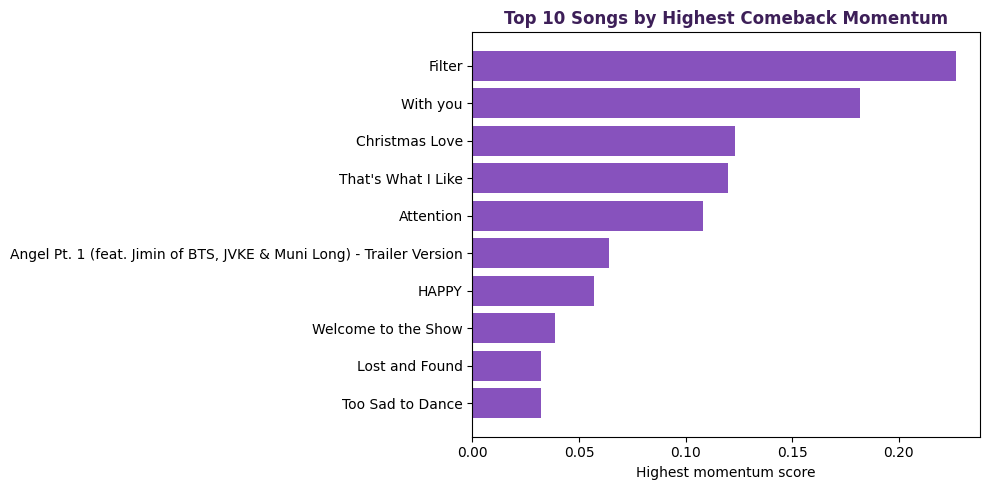

In [21]:
top_10_momentum = song_momentum.head(10).copy()

plt.figure(figsize=(10, 5))
plt.barh(
    top_10_momentum.sort_values("highest_momentum_score")["song"],
    top_10_momentum.sort_values("highest_momentum_score")["highest_momentum_score"],
    color=MID_PURPLE
)
plt.title("Top 10 Songs by Highest Comeback Momentum",
          color=DARK_PURPLE, fontweight="bold")
plt.xlabel("Highest momentum score")
plt.tight_layout()
plt.show()


In [22]:
momentum_df.to_csv(output_dir / "phase4_comeback_momentum_events.csv", index=False)
song_momentum.to_csv(output_dir / "phase4_song_momentum_summary.csv", index=False)
top_10_momentum.to_csv(output_dir / "phase4_top10_comeback_songs.csv", index=False)

print("Phase 4 outputs saved.")


Phase 4 outputs saved.


# Phase 5 — Fandom Intensity
### Goal
Create a transparent, project-specific index from:
- re-entry frequency,
- average chart strength during re-entry,
- average comeback momentum.


In [23]:
fandom_df = song_momentum.copy()

# Frequency normalized against the strongest re-entry frequency.
max_frequency = fandom_df["total_reentries"].max()
fandom_df["normalized_frequency"] = (
    fandom_df["total_reentries"] / max_frequency
)

# Higher chart position = stronger chart strength.
fandom_df["chart_strength"] = (
    (51 - fandom_df["average_reentry_position"]) / 50
)

fandom_df["fandom_intensity_score"] = (
    0.40 * fandom_df["normalized_frequency"]
    + 0.30 * fandom_df["chart_strength"]
    + 0.30 * fandom_df["average_momentum_score"]
)

def categorize_fandom(score):
    if score >= 0.60:
        return "Very High"
    if score >= 0.40:
        return "High"
    if score >= 0.20:
        return "Medium"
    return "Low"

fandom_df["fandom_category"] = (
    fandom_df["fandom_intensity_score"].apply(categorize_fandom)
)

fandom_df = fandom_df.sort_values(
    "fandom_intensity_score", ascending=False
).reset_index(drop=True)

display(fandom_df.head(10))


,song,artist,total_reentries,average_gap_days,longest_gap_days,best_reentry_position,average_reentry_position,highest_momentum_score,average_momentum_score,normalized_frequency,chart_strength,fandom_intensity_score,fandom_category
0,"Our Blues, Our Life",Lim Young Woong,31,3.9677,20.0000,37,46.0000,0.0022,0.0007,1.0000,0.1000,0.4302,High
1,Ditto,NewJeans,27,7.0370,28.0000,39,47.1481,0.0051,0.0011,0.8710,0.0770,0.3718,Medium
2,Seven (feat. Latto) (Explicit Ver.),Jung Kook,4,2.0000,2.0000,2,2.2500,0.0039,0.0038,0.1290,0.9750,0.3453,Medium
3,Interlude : Dive,Jimin,21,3.0952,7.0000,24,40.0476,0.0039,0.0013,0.6774,0.2190,0.3371,Medium
4,A bientot,Lim Young Woong,24,7.1667,48.0000,38,46.7083,0.0113,0.0012,0.7742,0.0858,0.3358,Medium
5,Standing Next to You,Jung Kook,5,2.0000,2.0000,5,8.2000,0.0036,0.0034,0.1613,0.8560,0.3223,Medium
6,New Jeans,NewJeans,23,9.2609,63.0000,40,46.8696,0.0174,0.0018,0.7419,0.0826,0.3221,Medium
7,Closer Than This,Jimin,4,2.0000,2.0000,5,6.5000,0.0036,0.0035,0.1290,0.8900,0.3197,Medium
8,3D (feat. Jack Harlow),Jung Kook,4,2.0000,2.0000,5,6.5000,0.0036,0.0035,0.1290,0.8900,0.3197,Medium
9,Like Crazy (English Version),Jimin,3,2.0000,2.0000,3,4.6667,0.0038,0.0036,0.0968,0.9267,0.3178,Medium


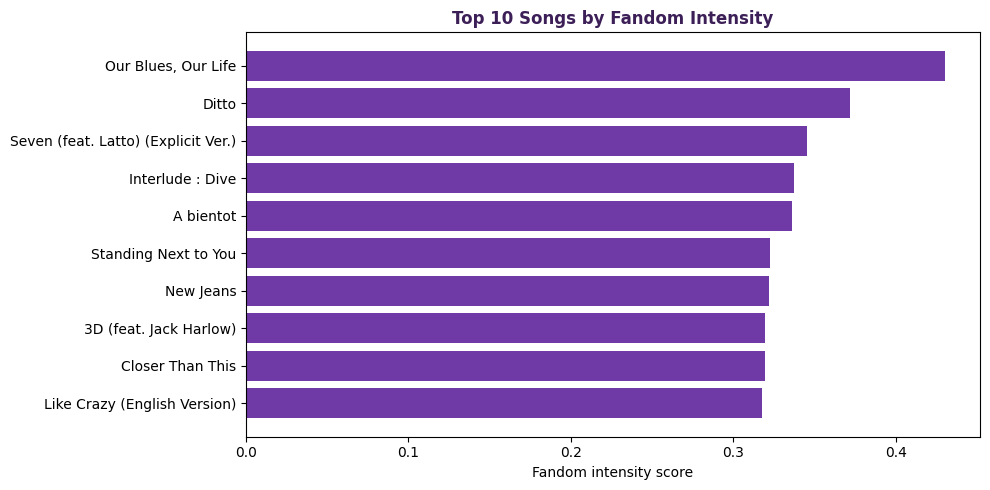

In [24]:
top_10_fandom = fandom_df.head(10)

plt.figure(figsize=(10, 5))
plt.barh(
    top_10_fandom.sort_values("fandom_intensity_score")["song"],
    top_10_fandom.sort_values("fandom_intensity_score")["fandom_intensity_score"],
    color=PURPLE
)
plt.title("Top 10 Songs by Fandom Intensity",
          color=DARK_PURPLE, fontweight="bold")
plt.xlabel("Fandom intensity score")
plt.tight_layout()
plt.show()


In [25]:
# Momentum vs fandom relationship.
momentum_fandom_correlation = (
    fandom_df["average_momentum_score"]
    .corr(fandom_df["fandom_intensity_score"])
)

print(f"Momentum–fandom correlation: {momentum_fandom_correlation:.4f}")


Momentum–fandom correlation: 0.0682


In [26]:
fandom_df.to_csv(
    output_dir / "phase5_fandom_intensity_song_analysis.csv",
    index=False
)
top_10_fandom.to_csv(
    output_dir / "phase5_top10_fandom_songs.csv",
    index=False
)

print("Phase 5 outputs saved.")


Phase 5 outputs saved.


# Phase 6 — Chart Sustainability & Artist Impact
### Goal
Measure sustained chart presence by combining:
- re-entry frequency,
- chart strength,
- average momentum,
- fandom intensity.


In [27]:
sustainability_df = fandom_df.copy()

sustainability_df["reentry_strength"] = (
    (51 - sustainability_df["best_reentry_position"]) / 50
)

sustainability_df["sustainability_score"] = (
    0.25 * sustainability_df["normalized_frequency"]
    + 0.25 * sustainability_df["chart_strength"]
    + 0.25 * sustainability_df["average_momentum_score"]
    + 0.25 * sustainability_df["fandom_intensity_score"]
)

sustainability_df = sustainability_df.sort_values(
    "sustainability_score", ascending=False
).reset_index(drop=True)

display(sustainability_df.head(10))


,song,artist,total_reentries,average_gap_days,longest_gap_days,best_reentry_position,average_reentry_position,highest_momentum_score,average_momentum_score,normalized_frequency,chart_strength,fandom_intensity_score,fandom_category,reentry_strength,sustainability_score
0,"Our Blues, Our Life",Lim Young Woong,31,3.9677,20.0000,37,46.0000,0.0022,0.0007,1.0000,0.1000,0.4302,High,0.2800,0.3827
1,Seven (feat. Latto) (Explicit Ver.),Jung Kook,4,2.0000,2.0000,2,2.2500,0.0039,0.0038,0.1290,0.9750,0.3453,Medium,0.9800,0.3633
2,Seven (feat. Latto) (Explicit Ver.),Jung Kook & Latto,1,3.0000,3.0000,1,1.0000,0.0059,0.0059,0.0323,1.0000,0.3147,Medium,1.0000,0.3382
3,Who,Jimin,1,2.0000,2.0000,1,1.0000,0.0039,0.0039,0.0323,1.0000,0.3141,Medium,1.0000,0.3376
4,Like Crazy (English Version),Jimin,3,2.0000,2.0000,3,4.6667,0.0038,0.0036,0.0968,0.9267,0.3178,Medium,0.9600,0.3362
5,Standing Next to You,Jung Kook,5,2.0000,2.0000,5,8.2000,0.0036,0.0034,0.1613,0.8560,0.3223,Medium,0.9200,0.3357
6,Closer Than This,Jimin,4,2.0000,2.0000,5,6.5000,0.0036,0.0035,0.1290,0.8900,0.3197,Medium,0.9200,0.3356
7,3D (feat. Jack Harlow),Jung Kook,4,2.0000,2.0000,5,6.5000,0.0036,0.0035,0.1290,0.8900,0.3197,Medium,0.9200,0.3356
8,Smeraldo Garden Marching Band (feat. Loco),Jimin & Loco,1,2.0000,2.0000,2,2.0000,0.0039,0.0039,0.0323,0.9800,0.3081,Medium,0.9800,0.3310
9,Ditto,NewJeans,27,7.0370,28.0000,39,47.1481,0.0051,0.0011,0.8710,0.0770,0.3718,Medium,0.2400,0.3302


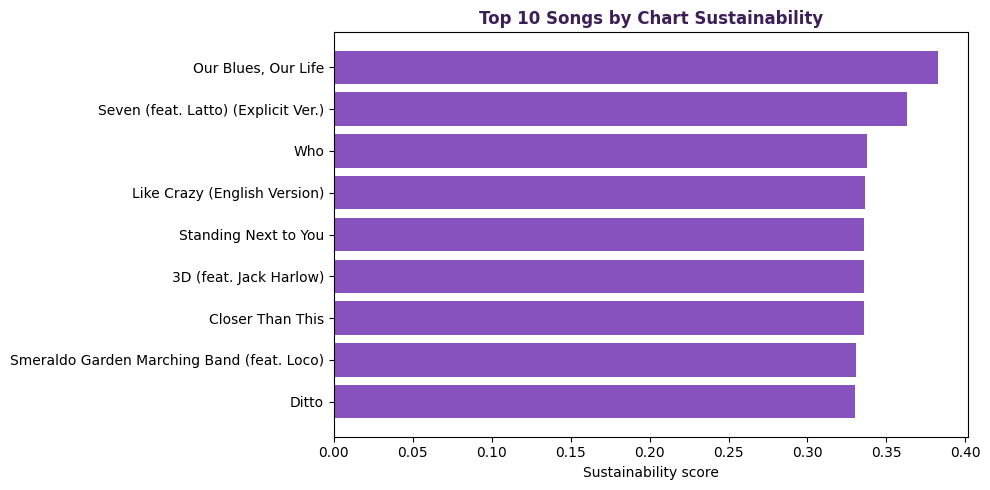

In [28]:
top_10_sustainable = sustainability_df.head(10)

plt.figure(figsize=(10, 5))
plt.barh(
    top_10_sustainable.sort_values("sustainability_score")["song"],
    top_10_sustainable.sort_values("sustainability_score")["sustainability_score"],
    color=MID_PURPLE
)
plt.title("Top 10 Songs by Chart Sustainability",
          color=DARK_PURPLE, fontweight="bold")
plt.xlabel("Sustainability score")
plt.tight_layout()
plt.show()


In [29]:
# Artist-level sustainability analysis.
artist_sustainability = (
    sustainability_df.groupby("artist", as_index=False)
    .agg(
        songs_with_reentry=("song", "nunique"),
        total_reentries=("total_reentries", "sum"),
        average_momentum_score=("average_momentum_score", "mean"),
        average_fandom_intensity=("fandom_intensity_score", "mean"),
        average_sustainability_score=("sustainability_score", "mean"),
    )
    .sort_values("average_sustainability_score", ascending=False)
    .reset_index(drop=True)
)

top_10_sustainable_artists = artist_sustainability.head(10)

display(top_10_sustainable_artists)


,artist,songs_with_reentry,total_reentries,average_momentum_score,average_fandom_intensity,average_sustainability_score
0,Jimin & Loco,1,1,0.0039,0.3081,0.3310
1,KingLee & Lil' Flip,1,1,0.0322,0.2806,0.3012
2,YANGHONGWON,1,1,0.0055,0.2246,0.2406
3,Jimin,24,151,0.0027,0.2182,0.2194
4,NewJeans,12,134,0.0026,0.2257,0.2145
5,BIBI,1,3,0.0023,0.2034,0.2123
6,Mariah Carey,1,1,0.0064,0.1768,0.1889
7,Jung Kook & Latto,5,8,0.0034,0.1777,0.1882
8,J Money & KingLee,1,1,0.0256,0.1706,0.1821
9,Jung Kook,14,84,0.0022,0.1725,0.1708


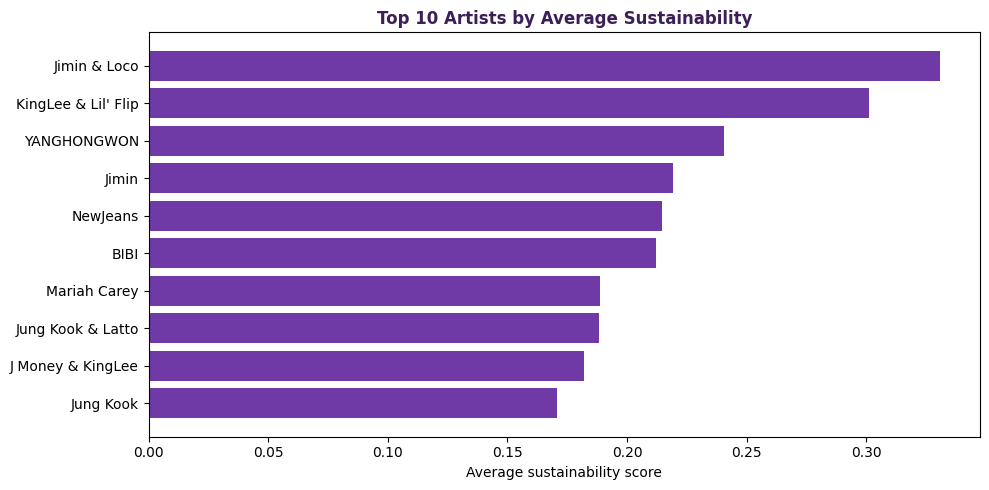

In [30]:
plt.figure(figsize=(10, 5))
artist_plot = top_10_sustainable_artists.sort_values(
    "average_sustainability_score"
)

plt.barh(
    artist_plot["artist"],
    artist_plot["average_sustainability_score"],
    color=PURPLE
)
plt.title("Top 10 Artists by Average Sustainability",
          color=DARK_PURPLE, fontweight="bold")
plt.xlabel("Average sustainability score")
plt.tight_layout()
plt.show()


In [31]:
sustainability_fandom_correlation = (
    sustainability_df["sustainability_score"]
    .corr(sustainability_df["fandom_intensity_score"])
)

print(
    f"Sustainability–fandom correlation: "
    f"{sustainability_fandom_correlation:.4f}"
)


Sustainability–fandom correlation: 0.9932


In [32]:
sustainability_df.to_csv(
    output_dir / "phase6_chart_sustainability_analysis.csv",
    index=False
)
artist_sustainability.to_csv(
    output_dir / "phase6_artist_sustainability_analysis.csv",
    index=False
)
top_10_sustainable.to_csv(
    output_dir / "phase6_top10_sustainable_songs.csv",
    index=False
)
top_10_sustainable_artists.to_csv(
    output_dir / "phase6_top10_sustainable_artists.csv",
    index=False
)

print("Phase 6 outputs saved.")


Phase 6 outputs saved.


# Phase 7 — Integrated K-pop Performance Analysis
### Goal
Combine the three major analytical dimensions into one comparable score:
- 35% sustainability
- 35% fandom intensity
- 30% average comeback momentum


In [33]:
integrated_df = sustainability_df.copy()

score_columns = [
    "average_momentum_score",
    "fandom_intensity_score",
    "sustainability_score",
]

for column in score_columns:
    min_value = integrated_df[column].min()
    max_value = integrated_df[column].max()

    if max_value == min_value:
        integrated_df[column + "_normalized"] = 0.0
    else:
        integrated_df[column + "_normalized"] = (
            (integrated_df[column] - min_value)
            / (max_value - min_value)
        )

integrated_df["overall_performance_score"] = (
    0.30 * integrated_df["average_momentum_score_normalized"]
    + 0.35 * integrated_df["fandom_intensity_score_normalized"]
    + 0.35 * integrated_df["sustainability_score_normalized"]
)

integrated_df = integrated_df.sort_values(
    "overall_performance_score", ascending=False
).reset_index(drop=True)

integrated_df["overall_rank"] = np.arange(1, len(integrated_df) + 1)

top_10_overall = integrated_df.head(10).copy()

display(
    top_10_overall[
        [
            "overall_rank", "song", "artist",
            "average_momentum_score",
            "fandom_intensity_score",
            "sustainability_score",
            "overall_performance_score",
        ]
    ]
)


,overall_rank,song,artist,average_momentum_score,fandom_intensity_score,sustainability_score,overall_performance_score
0,1,"Our Blues, Our Life",Lim Young Woong,0.0007,0.4302,0.3827,0.7015
1,2,Seven (feat. Latto) (Explicit Ver.),Jung Kook,0.0038,0.3453,0.3633,0.6185
2,3,Ditto,NewJeans,0.0011,0.3718,0.3302,0.6024
3,4,Lost and Found,KingLee & Lil' Flip,0.0322,0.2806,0.3012,0.5748
4,5,Seven (feat. Latto) (Explicit Ver.),Jung Kook & Latto,0.0059,0.3147,0.3382,0.5736
5,6,Standing Next to You,Jung Kook,0.0034,0.3223,0.3357,0.5714
6,7,Closer Than This,Jimin,0.0035,0.3197,0.3356,0.5693
7,8,3D (feat. Jack Harlow),Jung Kook,0.0035,0.3197,0.3356,0.5693
8,9,Like Crazy (English Version),Jimin,0.0036,0.3178,0.3362,0.5687
9,10,Who,Jimin,0.0039,0.3141,0.3376,0.5675


In [34]:
# Performance balance: distance between the three normalized dimensions.
normalized_cols = [
    "average_momentum_score_normalized",
    "fandom_intensity_score_normalized",
    "sustainability_score_normalized",
]

integrated_df["performance_balance"] = (
    integrated_df[normalized_cols].max(axis=1)
    - integrated_df[normalized_cols].min(axis=1)
)

top_10_balanced = (
    integrated_df
    .sort_values(
        ["performance_balance", "overall_performance_score"],
        ascending=[True, False]
    )
    .head(10)
)

display(
    top_10_balanced[
        [
            "song", "artist",
            "average_momentum_score_normalized",
            "fandom_intensity_score_normalized",
            "sustainability_score_normalized",
            "performance_balance",
            "overall_performance_score",
        ]
    ]
)


,song,artist,average_momentum_score_normalized,fandom_intensity_score_normalized,sustainability_score_normalized,performance_balance,overall_performance_score
256,euphoria,Kendrick Lamar,0.0000,0.0000,0.0000,0.0000,0.0000
257,greedy,Tate McRae,0.0000,0.0000,0.0000,0.0000,0.0000
258,Love Lee,AKMU,0.0000,0.0000,0.0000,0.0000,0.0000
259,Thirsty,aespa,0.0000,0.0000,0.0000,0.0000,0.0000
254,Girls Never Die,tripleS,0.0003,0.0000,0.0000,0.0003,0.0001
255,Tick-Tack,ILLIT,0.0003,0.0000,0.0000,0.0003,0.0001
251,3D (feat. Jack Harlow) (Instrumental),Jung Kook & Jack Harlow,0.0007,0.0001,0.0001,0.0006,0.0002
252,SHEESH,BABYMONSTER,0.0007,0.0001,0.0001,0.0006,0.0002
253,I Had Some Help (Feat. Morgan Wallen),Post Malone & Morgan Wallen,0.0007,0.0001,0.0001,0.0006,0.0002
250,Cupid,FIFTY FIFTY,0.0010,0.0001,0.0001,0.0009,0.0004


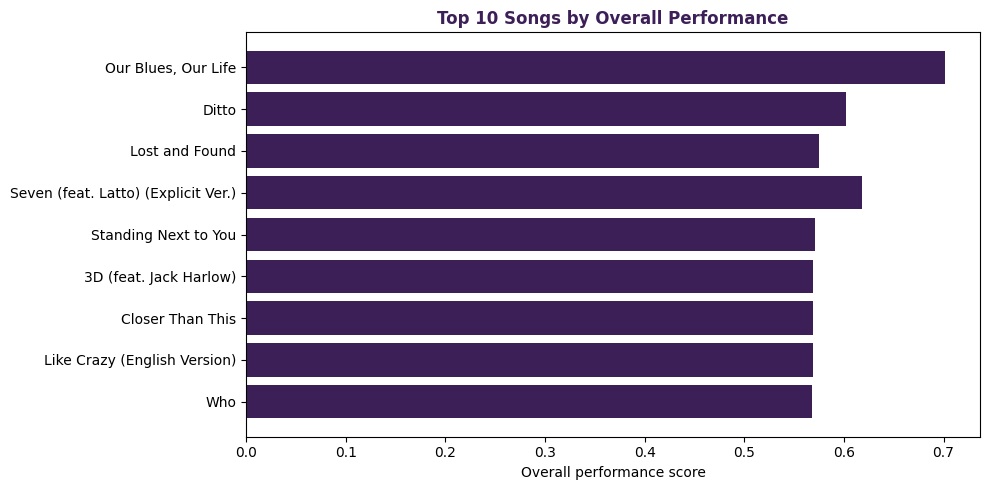

In [35]:
# Purple visualization: integrated top 10.
plot_df = top_10_overall.sort_values("overall_performance_score")

plt.figure(figsize=(10, 5))
plt.barh(
    plot_df["song"],
    plot_df["overall_performance_score"],
    color=DARK_PURPLE
)
plt.title("Top 10 Songs by Overall Performance",
          color=DARK_PURPLE, fontweight="bold")
plt.xlabel("Overall performance score")
plt.tight_layout()
plt.show()


In [36]:
integrated_df.to_csv(
    output_dir / "phase7_integrated_kpop_analysis.csv",
    index=False
)
top_10_overall.to_csv(
    output_dir / "phase7_top10_overall_songs.csv",
    index=False
)
top_10_balanced.to_csv(
    output_dir / "phase7_top10_balanced_performers.csv",
    index=False
)

print("Phase 7 outputs saved.")


Phase 7 outputs saved.


# Phase 8 — Dashboard-Ready Dataset & Storytelling
### Goal
Create clean, compact files for the Streamlit dashboard without requiring the dashboard to redo analytical calculations.


In [37]:
dashboard_df = integrated_df.copy()

# Add album-cover URLs directly to the dashboard dataset.
cover_lookup = (
    df_clean[["song", "artist", "album_cover_url"]]
    .drop_duplicates(["song", "artist"])
)

dashboard_df = dashboard_df.merge(
    cover_lookup,
    on=["song", "artist"],
    how="left"
)

dashboard_df["album_cover_url"] = dashboard_df["album_cover_url"].fillna("")

dashboard_top10 = dashboard_df.head(10).copy()

# A separate all-song master table is useful for dashboard filters and Song Explorer.
all_song_summary = (
    df_clean.groupby(["song", "artist"], as_index=False)
    .agg(
        chart_appearance_days=("date", "nunique"),
        best_chart_position=("position", "min"),
        average_chart_position=("position", "mean"),
        average_popularity=("popularity", "mean"),
        total_chart_rows=("song", "size"),
        album_type=("album_type", "first"),
        is_explicit=("is_explicit", "max"),
        album_cover_url=("album_cover_url", "first"),
    )
)

all_song_summary["chart_presence_rate"] = (
    all_song_summary["chart_appearance_days"] / df_clean["date"].nunique()
)

all_song_summary = all_song_summary.sort_values(
    ["best_chart_position", "average_popularity"],
    ascending=[True, False]
).reset_index(drop=True)

dashboard_kpis = pd.DataFrame({
    "metric": [
        "Unique song titles",
        "Unique song-artist combinations",
        "Songs with at least one re-entry",
        "Total re-entry events",
        "Average comeback gap",
        "Unique artists",
        "Top overall song",
    ],
    "value": [
        df_clean["song"].nunique(),
        df_clean[["song", "artist"]].drop_duplicates().shape[0],
        dashboard_df[["song", "artist"]].drop_duplicates().shape[0],
        len(reentry_summary),
        round(reentry_summary["gap_days"].mean(), 2),
        df_clean["artist"].nunique(),
        dashboard_top10.iloc[0]["song"],
    ],
})

display(dashboard_kpis)
display(dashboard_top10[
    [
        "overall_rank", "song", "artist",
        "album_cover_url",
        "total_reentries",
        "average_gap_days",
        "average_momentum_score",
        "fandom_intensity_score",
        "sustainability_score",
        "overall_performance_score",
    ]
])


,metric,value
0,Unique song titles,527
1,Unique song-artist combinations,541
2,Songs with at least one re-entry,260
3,Total re-entry events,1067
4,Average comeback gap,8.6800
5,Unique artists,194
6,Top overall song,"Our Blues, Our Life"


,overall_rank,song,artist,album_cover_url,total_reentries,average_gap_days,average_momentum_score,fandom_intensity_score,sustainability_score,overall_performance_score
0,1,"Our Blues, Our Life",Lim Young Woong,https://i.scdn.co/image/ab67616d0000b2738f116e476da669a9a3e7dcaa,31,3.9677,0.0007,0.4302,0.3827,0.7015
1,2,Seven (feat. Latto) (Explicit Ver.),Jung Kook,https://i.scdn.co/image/ab67616d0000b273741fd4807f442af3f7359316,4,2.0000,0.0038,0.3453,0.3633,0.6185
2,3,Ditto,NewJeans,https://i.scdn.co/image/ab67616d0000b273edf5b257be1d6593e81bb45f,27,7.0370,0.0011,0.3718,0.3302,0.6024
3,4,Lost and Found,KingLee & Lil' Flip,https://i.scdn.co/image/ab67616d0000b273a7d4b25864eb074831afc0e9,1,19.0000,0.0322,0.2806,0.3012,0.5748
4,5,Seven (feat. Latto) (Explicit Ver.),Jung Kook & Latto,https://i.scdn.co/image/ab67616d0000b273bf5cce5a0e1ed03a626bdd74,1,3.0000,0.0059,0.3147,0.3382,0.5736
5,6,Standing Next to You,Jung Kook,https://i.scdn.co/image/ab67616d0000b273741fd4807f442af3f7359316,5,2.0000,0.0034,0.3223,0.3357,0.5714
6,7,Closer Than This,Jimin,https://i.scdn.co/image/ab67616d0000b273e3dbc03f538633dbb40adf37,4,2.0000,0.0035,0.3197,0.3356,0.5693
7,8,3D (feat. Jack Harlow),Jung Kook,https://i.scdn.co/image/ab67616d0000b27399583bb32b47e87d55c6064b,4,2.0000,0.0035,0.3197,0.3356,0.5693
8,9,Like Crazy (English Version),Jimin,https://i.scdn.co/image/ab67616d0000b2732b46078245d0120690eb560d,3,2.0000,0.0036,0.3178,0.3362,0.5687
9,10,Who,Jimin,https://i.scdn.co/image/ab67616d0000b273f02c451189a709b9a952aaec,1,2.0000,0.0039,0.3141,0.3376,0.5675


In [38]:
# Final dashboard exports.
dashboard_df.to_csv(
    output_dir / "KPOP_FINAL_DASHBOARD_DATA.csv",
    index=False
)

dashboard_top10.to_csv(
    output_dir / "KPOP_FINAL_TOP_SONGS.csv",
    index=False
)

dashboard_kpis.to_csv(
    output_dir / "KPOP_FINAL_KPIS.csv",
    index=False
)

# All 527-ish unique songs, including songs without re-entry.
all_song_summary.to_csv(
    output_dir / "KPOP_FINAL_ALL_SONGS.csv",
    index=False
)

# Artist-level analytical output.
artist_dashboard = artist_sustainability.copy()
artist_dashboard.to_csv(
    output_dir / "KPOP_FINAL_ARTIST_ANALYSIS.csv",
    index=False
)

print("Dashboard-ready exports created.")
print("Re-entry analysis rows:", len(dashboard_df))
print("All unique song rows:", len(all_song_summary))


Dashboard-ready exports created.
Re-entry analysis rows: 260
All unique song rows: 541


In [39]:
# Key project findings.
top_song = dashboard_top10.iloc[0]
highest_momentum_song = dashboard_df.sort_values(
    "average_momentum_score", ascending=False
).iloc[0]
highest_fandom_song = dashboard_df.sort_values(
    "fandom_intensity_score", ascending=False
).iloc[0]
highest_sustainability_song = dashboard_df.sort_values(
    "sustainability_score", ascending=False
).iloc[0]

final_summary = {
    "top_overall_song": f"{top_song['song']} — {top_song['artist']}",
    "highest_momentum_song": f"{highest_momentum_song['song']} — {highest_momentum_song['artist']}",
    "highest_fandom_intensity_song": f"{highest_fandom_song['song']} — {highest_fandom_song['artist']}",
    "highest_sustainability_song": f"{highest_sustainability_song['song']} — {highest_sustainability_song['artist']}",
    "reentry_events": len(reentry_summary),
    "songs_with_reentry": reentry_summary[["song", "artist"]].drop_duplicates().shape[0],
    "average_reentry_gap_days": round(reentry_summary["gap_days"].mean(), 2),
    "longest_reentry_gap_days": int(reentry_summary["gap_days"].max()),
}

display(pd.DataFrame(final_summary.items(), columns=["metric", "value"]))


,metric,value
0,top_overall_song,"Our Blues, Our Life — Lim Young Woong"
1,highest_momentum_song,That's What I Like — Bruno Mars
2,highest_fandom_intensity_song,"Our Blues, Our Life — Lim Young Woong"
3,highest_sustainability_song,"Our Blues, Our Life — Lim Young Woong"
4,reentry_events,1067
5,songs_with_reentry,260
6,average_reentry_gap_days,8.6800
7,longest_reentry_gap_days,508


# Phase 9 — Final Validation & Submission Check
### Goal
Confirm that the final analytical objects and exported files are internally consistent.


In [40]:
# Final score-range validation.
score_checks = {
    "momentum_0_to_1": integrated_df["average_momentum_score"].between(0, 1).all(),
    "fandom_0_to_1": integrated_df["fandom_intensity_score"].between(0, 1).all(),
    "sustainability_0_to_1": integrated_df["sustainability_score"].between(0, 1).all(),
    "overall_0_to_1": integrated_df["overall_performance_score"].between(0, 1).all(),
}

display(pd.DataFrame(score_checks.items(), columns=["check", "passed"]))

assert all(score_checks.values())
assert integrated_df["overall_rank"].is_unique
assert integrated_df["overall_rank"].min() == 1
assert integrated_df["overall_rank"].max() == len(integrated_df)


,check,passed
0,momentum_0_to_1,True
1,fandom_0_to_1,True
2,sustainability_0_to_1,True
3,overall_0_to_1,True


In [41]:
# Final structural validation.
required_objects = {
    "df_clean": df_clean,
    "reentry_summary": reentry_summary,
    "momentum_df": momentum_df,
    "song_momentum": song_momentum,
    "fandom_df": fandom_df,
    "sustainability_df": sustainability_df,
    "artist_sustainability": artist_sustainability,
    "integrated_df": integrated_df,
    "dashboard_df": dashboard_df,
}

final_object_check = pd.DataFrame({
    "object": list(required_objects.keys()),
    "rows": [len(v) for v in required_objects.values()],
    "columns": [len(v.columns) for v in required_objects.values()],
})

display(final_object_check)
assert all(len(v) > 0 for v in required_objects.values())


,object,rows,columns
0,df_clean,27750,11
1,reentry_summary,1067,7
2,momentum_df,1067,10
3,song_momentum,260,9
4,fandom_df,260,13
5,sustainability_df,260,15
6,artist_sustainability,118,6
7,integrated_df,260,21
8,dashboard_df,260,22


In [42]:
# Confirm all required output files exist.
required_outputs = [
    "KPOP_Cleaned_Master.csv",
    "phase3_reentry_events.csv",
    "phase3_reentry_frequency.csv",
    "phase4_comeback_momentum_events.csv",
    "phase4_song_momentum_summary.csv",
    "phase5_fandom_intensity_song_analysis.csv",
    "phase6_chart_sustainability_analysis.csv",
    "phase6_artist_sustainability_analysis.csv",
    "phase7_integrated_kpop_analysis.csv",
    "phase7_top10_overall_songs.csv",
    "KPOP_FINAL_DASHBOARD_DATA.csv",
    "KPOP_FINAL_TOP_SONGS.csv",
    "KPOP_FINAL_ALL_SONGS.csv",
    "KPOP_FINAL_KPIS.csv",
    "KPOP_FINAL_ARTIST_ANALYSIS.csv",
]

output_check = pd.DataFrame({
    "file": required_outputs,
    "exists": [(output_dir / f).exists() for f in required_outputs],
})

display(output_check)
assert output_check["exists"].all()

print("\nFINAL PROJECT VALIDATION: PASS")
print("Notebook is ready for dashboard integration and submission.")


,file,exists
0,KPOP_Cleaned_Master.csv,True
1,phase3_reentry_events.csv,True
2,phase3_reentry_frequency.csv,True
3,phase4_comeback_momentum_events.csv,True
4,phase4_song_momentum_summary.csv,True
5,phase5_fandom_intensity_song_analysis.csv,True
6,phase6_chart_sustainability_analysis.csv,True
7,phase6_artist_sustainability_analysis.csv,True
8,phase7_integrated_kpop_analysis.csv,True
9,phase7_top10_overall_songs.csv,True



FINAL PROJECT VALIDATION: PASS
Notebook is ready for dashboard integration and submission.


# Final Submission Checklist

### Data
- [x] Raw dataset preserved.
- [x] Exact duplicates handled.
- [x] Duplicate date-position anomaly handled deterministically.
- [x] Dates standardized.
- [x] Required fields validated.
- [x] Exactly 50 chart positions per date after cleaning.

### Analysis
- [x] EDA completed.
- [x] Chart re-entry detection completed.
- [x] Comeback momentum completed.
- [x] Fandom intensity completed.
- [x] Sustainability completed.
- [x] Artist-level analysis completed.
- [x] Integrated performance score completed.
- [x] Final rankings generated.

### Dashboard
- [x] Dashboard-ready song dataset.
- [x] Album-cover URLs included.
- [x] Top-song ranking export.
- [x] KPI export.
- [x] Artist analysis export.

### Important interpretation note
The project scores are analytical indices designed for comparison within this dataset. They should not be presented as direct measurements of fandom size or universal popularity.
